# LiteALPR Demo
Welcome to the official demo for **LiteALPR**, an extremely fast and accurate License Plate Recognition system built on YOLOv8n-Efficient and SVTR26-Tiny. This notebook is designed to help you get started quickly.

In [1]:
# Install the necessary libraries
!pip install litealpr huggingface_hub opencv-python matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.8/15.8 MB 77.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 484.3/484.3 kB 43.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 976.9/976.9 kB 65.8 MB/s eta 0:00:00
  Created wheel for numpy: filename=numpy-1.26.4-cp313-cp313-linux_x86_64.whl size=6917454 sha256=d064c66f2d1da11471777c8efb70c1fda180f7b3d487322d076e3fd146de6804
  Stored in directory: /root/.cache/pip/wheels/8b/2d/9f/b6b46373f328e2ef50388915d351ccacbedac929459b5459bf
Su

## 1. Import and Initialize
The `LiteALPR` class will automatically download the pre-trained weights (`YOLOv8n-Efficient` and `SVTR26-Tiny`) from Hugging Face if you don't provide local paths.

In [1]:
import cv2
import matplotlib.pyplot as plt
from litealpr.pipeline import LiteALPR

# Initialize the End-to-End Pipeline
model = LiteALPR(device='cuda:0') # Use 'cpu' if you want to use CPU

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
[LiteALPR] Initializing on cuda:0...
[LiteALPR] Downloading/Verifying yolov8n_efficient/best.pt from HuggingFace...


yolov8n_efficient/best.pt:   0%|          | 0.00/4.28M [00:00<?, ?B/s]

[LiteALPR] Loading Detection Model: /root/.cache/huggingface/hub/models--anhone3--LiteALPR/snapshots/f91ff626d981ff7d2355aac16d66a0a6b5943757/yolov8n_efficient/best.pt
our_YOLOv8n_efficient summary (fused): 141 layers, 1,993,871 parameters, 0 gradients, 5.6 GFLOPs
[LiteALPR] Downloading/Verifying svtr26_tiny/best.pth from HuggingFace...


svtr26_tiny/best.pth:   0%|          | 0.00/16.9M [00:00<?, ?B/s]

[LiteALPR] Loading Recognition Model: /root/.cache/huggingface/hub/models--anhone3--LiteALPR/snapshots/f91ff626d981ff7d2355aac16d66a0a6b5943757/svtr26_tiny/best.pth
[LiteALPR] Models loaded successfully!


## 2. Download Sample Image

In [3]:
import urllib.request

# Download a sample car image
image_url = 'https://raw.githubusercontent.com/vn-anhnth/LiteALPR/main/dataset/det/test/images/carlong_0178.png'
urllib.request.urlretrieve(image_url, 'sample.jpg')

('sample.jpg', <http.client.HTTPMessage at 0x7d8caca79a90>)

## 3. Run Inference

In [4]:
# Run inference
results = model.read('sample.jpg')
print("Detected License Plates:")
for res in results:
    print(f"Text: {res['text']} | Confidence: {res['score']:.2f} | BBox: {res['box']}")

Detected License Plates:
Text: 51G51332 | Confidence: 1.00 | BBox: [168, 229, 271, 262]


## 4. Visualize Results

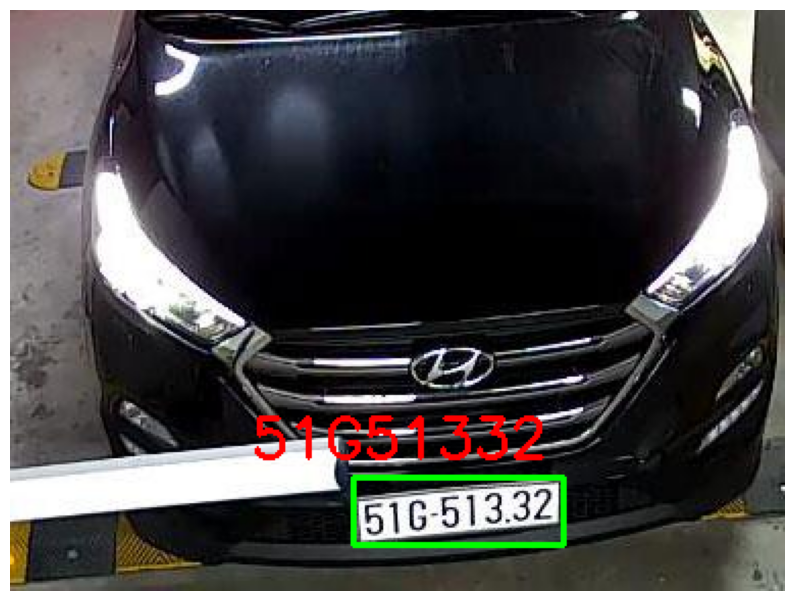

In [5]:
img = cv2.imread('sample.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

for res in results:
    x1, y1, x2, y2 = res['box']
    text = res['text']

    # Draw BBox
    cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
    # Draw Text
    cv2.putText(img, text, (x1 - 50, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 0, 0), 2)

plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.axis('off')
plt.show()

## 5. Crop

In [21]:
import os
import cv2

image_path = "sample.jpg"

# Read image
img = cv2.imread(image_path)

# Create directory for cropped images
save_dir = "/content/crops"
os.makedirs(save_dir, exist_ok=True)

# Get filename without extension
filename = os.path.splitext(os.path.basename(image_path))[0]

# Crop and save each detected license plate
for i, res in enumerate(results, start=1):
    x1, y1, x2, y2 = map(int, res["box"])

    crop = img[y1:y2, x1:x2]

    # If there is only one license plate, do not add an index
    if len(results) == 1:
        save_path = os.path.join(save_dir, f"{filename}_crop.jpg")
    else:
        save_path = os.path.join(save_dir, f"{filename}_crop_{i}.jpg")

    cv2.imwrite(save_path, crop)
    print(f"Saved: {save_path}")

Saved: /content/crops/sample_crop.jpg


## 6. Flexible API: Detect Only (YOLOv8n-Efficient)

In [18]:
model = LiteALPR(use_rec=False)
boxes = model.detect('sample.jpg')
print("Detected boxes:", boxes)

[LiteALPR] Initializing on cuda:0...
[LiteALPR] Downloading/Verifying yolov8n_efficient/best.pt from HuggingFace...
[LiteALPR] Loading Detection Model: /root/.cache/huggingface/hub/models--anhone3--LiteALPR/snapshots/f91ff626d981ff7d2355aac16d66a0a6b5943757/yolov8n_efficient/best.pt
our_YOLOv8n_efficient summary (fused): 141 layers, 1,993,871 parameters, 0 gradients, 5.6 GFLOPs
[LiteALPR] Models loaded successfully!
Detected boxes: [[168, 229, 271, 262]]


## 7. Flexible API: Recognize Only (SVTR26)

In [22]:
model = LiteALPR(use_det=False)
crop_img = cv2.imread('/content/crops/sample_crop.jpg')
text, score = model.recognize(crop_img)
print(f"Text: {text} (Score: {score})")

[LiteALPR] Initializing on cuda:0...
[LiteALPR] Downloading/Verifying svtr26_tiny/best.pth from HuggingFace...
[LiteALPR] Loading Recognition Model: /root/.cache/huggingface/hub/models--anhone3--LiteALPR/snapshots/f91ff626d981ff7d2355aac16d66a0a6b5943757/svtr26_tiny/best.pth
[LiteALPR] Models loaded successfully!
Text: 51G51332 (Score: 0.998908281326294)
